## Question 3

### **Radial Metallicity Relations in Simulations**

In [47]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
from scipy import stats 

*The radial metallicity relation describes the change of metallicity – here the gas-phase metallicity A(O) = log10(N_O/N_H) + 12 – with galactocentric cylindrical radius RGal.
. Radial
metallicity gradients provide insight into processes such as inside-out formation, gas accretion, outflows, and radial migration. A lot of work has been done through observational
studies (e.g. Ho et al., 2017, ApJ, 846, 39) and a few simulations (e.g. Grand et al., 2016,
MNRAS, 460, 94), but more works is needed to understand variations of the radial metallicity
gradient.*

*Your colleague has completed a cosmological simulation of a Milky-Way-like spiral galaxy.
The FITS file data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits
contains the gas-phase metallicity A(O) and (x, y, z) positions of gas particles within RGal. = sqrt(x^2+y^2) < 25 kpc. Perform the following tasks and save your figures in figures/:*

1.

*Plot a two-panel figure:*

*-(a) logarithmic density plot of RGal. vs. A(O), with a linear fit and legend;*

*-(b) residuals of the fit, RGal. vs. ∆A(O).*

In [2]:
data = fits.open('data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits')[1].data
# data is in columns [x, y, z, A_O]

x = data['x']
y = data['y']
z = data['z']
A_O = data['A_O']

R_gal = np.sqrt(x**2 + y**2)

In [3]:
import matplotlib.colors as colors

38774543.py: Linear fit parameters: m = -0.0342 ± 0.0000, p = 9.1278 ± 0.0002


/tmp/ipykernel_990765/38774543.py:21: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[0].legend(loc='lower left')


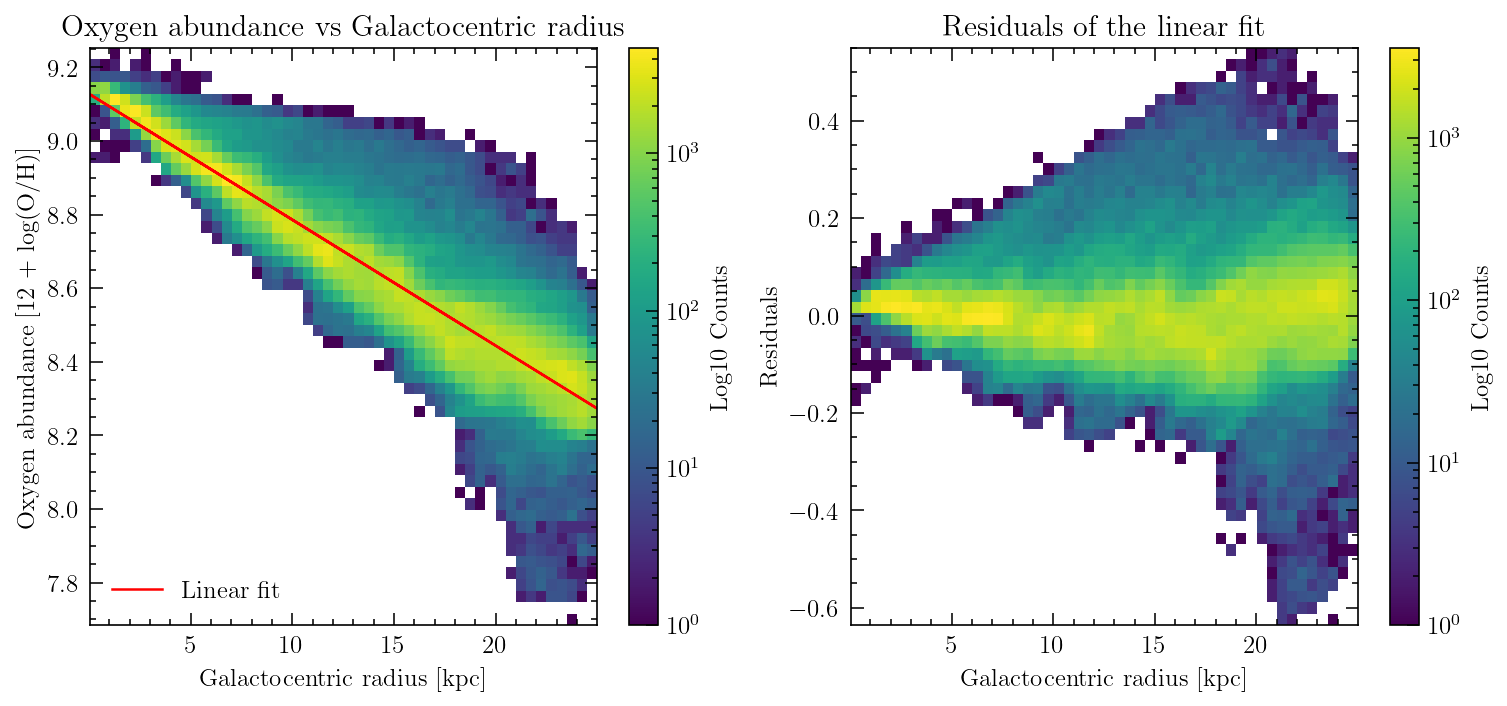

In [38]:
# two-panel figure
# a) logarithmic density plot of A_O vs R_gal, with a linear fit and legend
# b) residuals of the fit

def linear_func(x, m, p):
    return m * x + p
pcof, pcov = curve_fit(linear_func, R_gal, A_O)
pcor = np.sqrt(np.diag(pcov))
print(f"Linear fit parameters: m = {pcof[0]:.4f} ± {pcor[0]:.4f}, p = {pcof[1]:.4f} ± {pcor[1]:.4f}")

fitted = linear_func(R_gal, *pcof)
residuals = A_O - fitted

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist2d(R_gal, A_O, bins=50, norm=colors.LogNorm(), cmap='viridis', label='Simulation data')
plt.colorbar(axs[0].collections[0], label='Log10 Counts')
axs[0].set_xlabel('Galactocentric radius [kpc]')
axs[0].set_ylabel('Oxygen abundance [12 + log(O/H)]')
axs[0].set_title('Oxygen abundance vs Galactocentric radius')
axs[0].plot(R_gal, fitted, 'r-', label='Linear fit')
axs[0].legend(loc='lower left')

axs[1].hist2d(R_gal, residuals, bins=50, norm=colors.LogNorm(), cmap='viridis')
axs[1].set_xlabel('Galactocentric radius [kpc]')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residuals of the linear fit')

plt.colorbar(axs[1].collections[0], label='Log10 Counts')
#fig.savefig('figures/metallicity_radius.pdf', dpi=300)
fig.show()

2.

*Use a python fitting tool to fit a linear function to the data, reporting the intercept and
slope with uncertainties. Include any hyperparameters used.*

In [37]:
print(f"Linear fit parameters (A_O = m R_gal + p):")
print(f"m = {pcof[0]:.5f} ± {pcor[0]:.5f}")
print(f"p = {pcof[1]:.4f} ± {pcor[1]:.4f}")
print("No hyperparameters were used, the fit assumes independent measurements with equal weighting and Gaussian residuals.")

168632181.py: Linear fit parameters (A_O = m R_gal + p):
168632181.py: m = -0.03420 ± 0.00001
168632181.py: p = 9.1278 ± 0.0002
168632181.py: No hyperparameters were used, the fit assumes independent measurements with equal weighting and Gaussian residuals.


3.

*Discuss where the linear model fits well and where it does not. Use statistical metrics, such as the root mean square or another goodness-of-fit indicator, to quantify its
performance overall and in regions with larger residuals.*

In [12]:
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE of the fit: {rmse:.4f}")

ss_res = np.sum(residuals**2)
ss_tot = np.sum((A_O - np.mean(A_O))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared of the fit: {r_squared:.4f}")

4123136387.py: RMSE of the fit: 0.0726
4123136387.py: R-squared of the fit: 0.9125


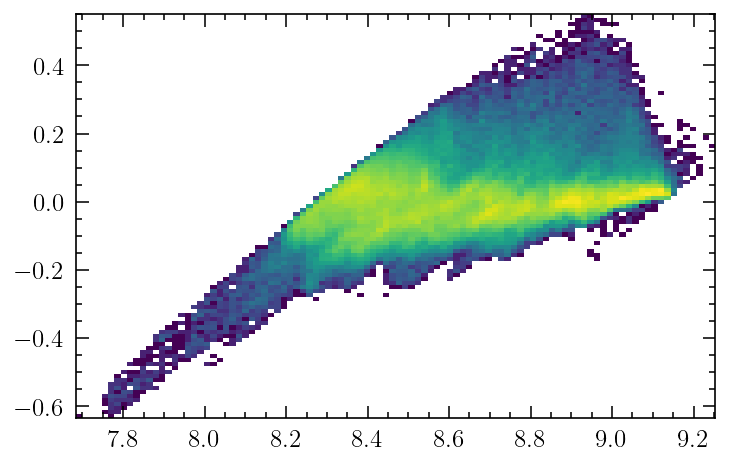

In [ ]:
# residuals have a larger scatter further out, which roughly
# correlates to higher residuals at larger metallicity (due to ~linear trend)

plt.hist2d(A_O, residuals, bins=100, norm=colors.LogNorm(), cmap='viridis')
plt.show()

In [13]:
radial_bins = [0, 5, 10, 15, 20, 25]

print("\nResidual statistics by radial region:")

for rmin, rmax in zip(radial_bins[:-1], radial_bins[1:]):

    region = (R_gal >= rmin) & (R_gal < rmax)

    if np.sum(region) == 0:
        continue

    region_residuals = residuals[region]

    region_rmse = np.sqrt(np.mean(region_residuals**2))
    region_mean = np.mean(region_residuals)
    region_std = np.std(region_residuals)
    ss_res_region = np.sum(region_residuals**2)
    ss_tot_region = np.sum((A_O[region] - np.mean(A_O[region]))**2)
    region_r_squared = 1 - (ss_res_region / ss_tot_region)

    print(
        f"{rmin:2d}-{rmax:2d} kpc: "
        f"N={np.sum(region):7d}, "
        f"R_squared={region_r_squared:.5f}, "
        f"std={region_std:.5f}, "
        f"RMSE={region_rmse:.5f}"
    )

933657819.py: 
Residual statistics by radial region:
933657819.py:  0- 5 kpc: N=  65587, R_squared=0.65648, std=0.02676, RMSE=0.03227
933657819.py:  5-10 kpc: N=  94246, R_squared=0.55807, std=0.04825, RMSE=0.04825
933657819.py: 10-15 kpc: N= 100223, R_squared=0.28647, std=0.06952, RMSE=0.07039
933657819.py: 15-20 kpc: N= 122081, R_squared=0.22197, std=0.08591, RMSE=0.08794
933657819.py: 20-25 kpc: N= 129383, R_squared=0.14273, std=0.08485, RMSE=0.08664


4.

*Plot a three-panel figure for the x vs. y plane using the same bins and sensible colormaps:*

*• (a) 2D histogram of the median simulated A(O);*

*• (b) 2D histogram of the median fitted A(O);*

*• (c) 2D histogram of the median residuals ∆A(O).*

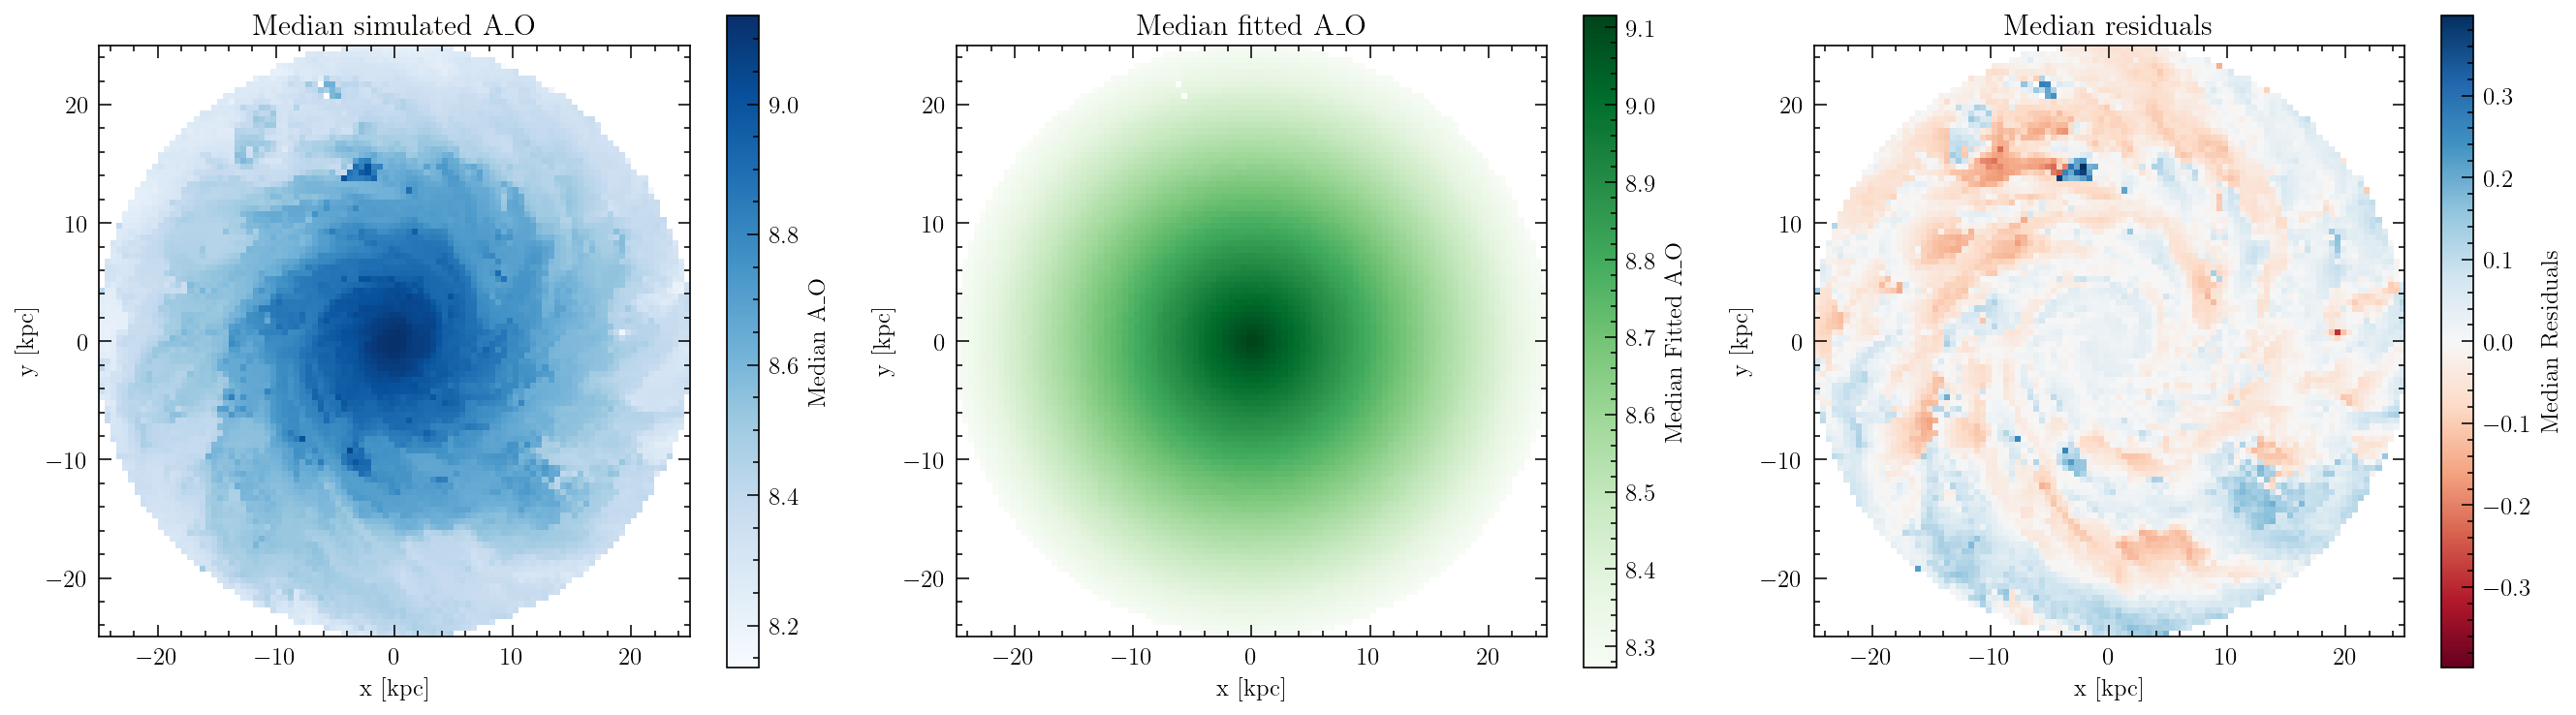

In [54]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, A_O, statistic='median', bins=100)
im = axs[0].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='Blues')
plt.colorbar(im, ax=axs[0], label='Median A_O')
axs[0].set_xlabel('x [kpc]')
axs[0].set_ylabel('y [kpc]')
axs[0].set_title('Median simulated A_O')

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, fitted, statistic='median', bins=100)
im = axs[1].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='Greens')
plt.colorbar(im, ax=axs[1], label='Median Fitted A_O')
axs[1].set_xlabel('x [kpc]')
axs[1].set_ylabel('y [kpc]')
axs[1].set_title('Median fitted A_O')

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, residuals, statistic='median', bins=100)
im = axs[2].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='RdBu', norm=colors.CenteredNorm(vcenter=0))
plt.colorbar(im, ax=axs[2], label='Median Residuals')
axs[2].set_xlabel('x [kpc]')
axs[2].set_ylabel('y [kpc]')
axs[2].set_title('Median residuals')

fig.savefig('figures/metallicity_xy_plane.pdf', dpi=300)
plt.tight_layout()
fig.show()

5.

*Describe your choice of 2D bins. Discuss what details would be missed with fewer bins and what problems could arise with more bins.*

In [ ]:
# what details are missed with fewer bins?

# otherwise, if there aretoo many bins, artefacts where some bins do not have any data, 
# so the median is not defined
# many bins produce many empty/noisy bins and make individual pixels dominated by very few particles

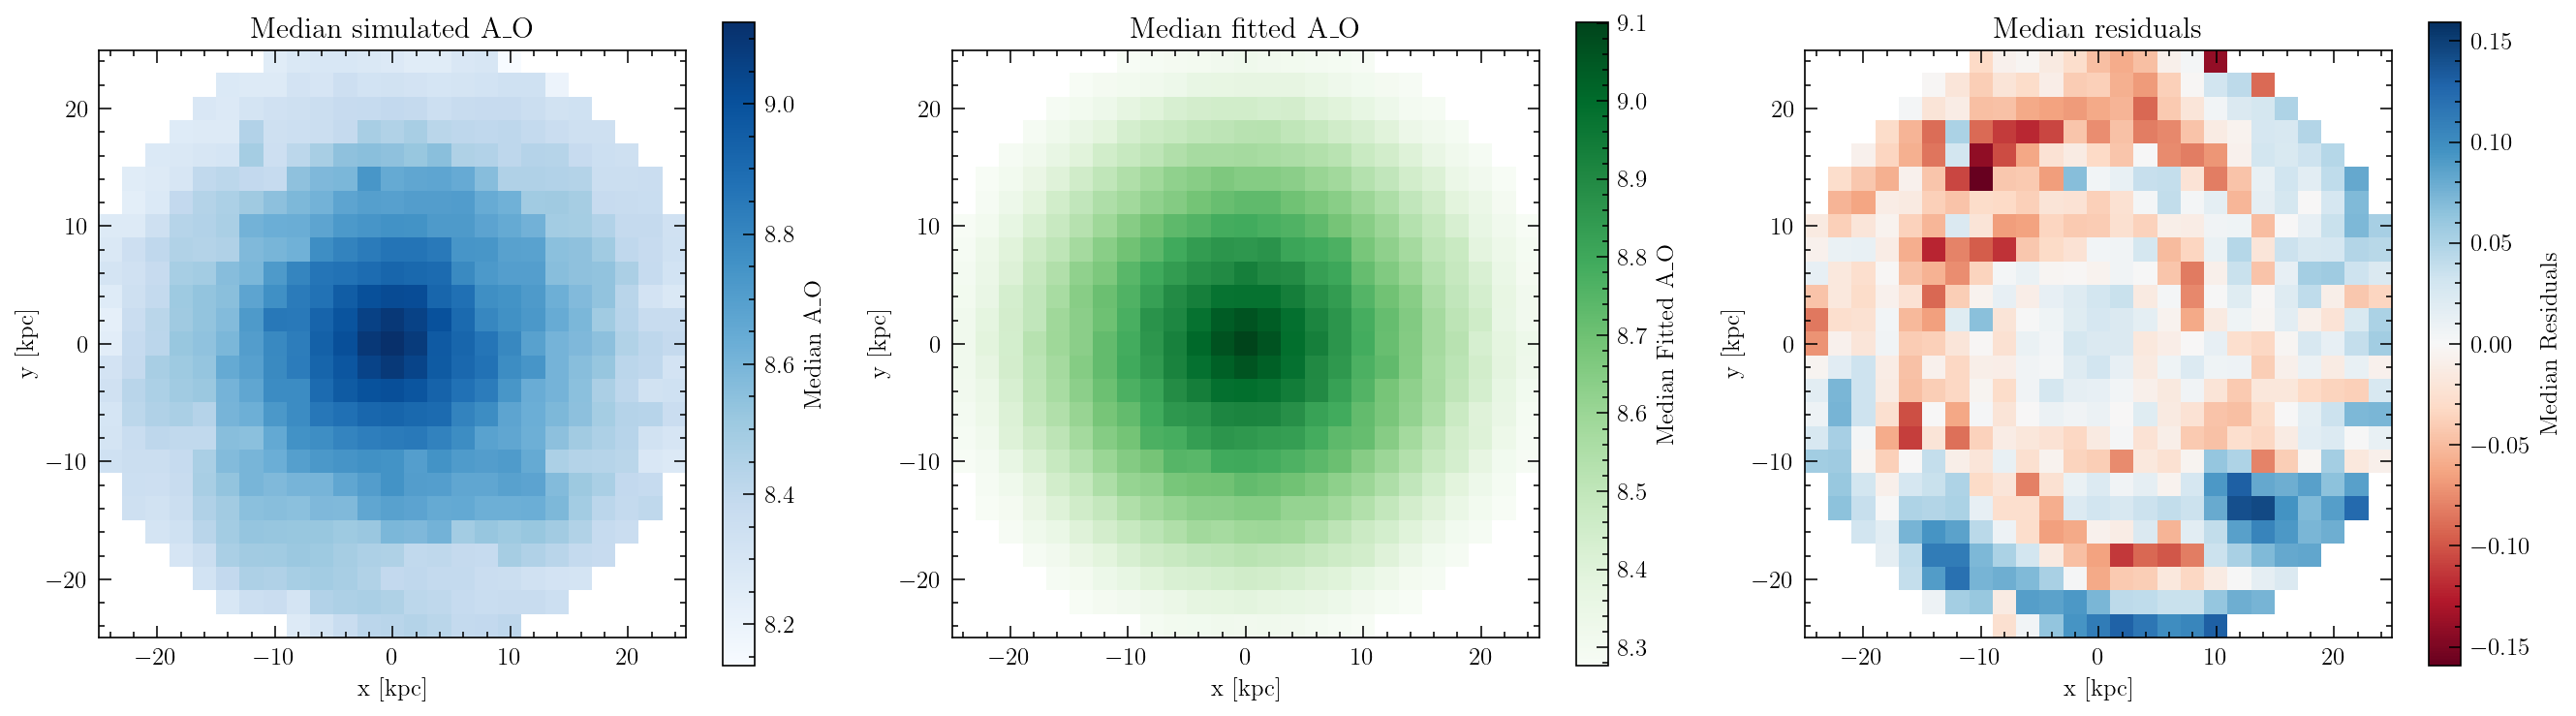

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, A_O, statistic='median', bins=25)
im = axs[0].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='Blues')
plt.colorbar(im, ax=axs[0], label='Median A_O')
axs[0].set_xlabel('x [kpc]')
axs[0].set_ylabel('y [kpc]')
axs[0].set_title('Median simulated A_O')

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, fitted, statistic='median', bins=25)
im = axs[1].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='Greens')
plt.colorbar(im, ax=axs[1], label='Median Fitted A_O')
axs[1].set_xlabel('x [kpc]')
axs[1].set_ylabel('y [kpc]')
axs[1].set_title('Median fitted A_O')

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, residuals, statistic='median', bins=25)
im = axs[2].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='RdBu', norm=colors.CenteredNorm(vcenter=0))
plt.colorbar(im, ax=axs[2], label='Median Residuals')
axs[2].set_xlabel('x [kpc]')
axs[2].set_ylabel('y [kpc]')
axs[2].set_title('Median residuals')

plt.tight_layout()
fig.show()

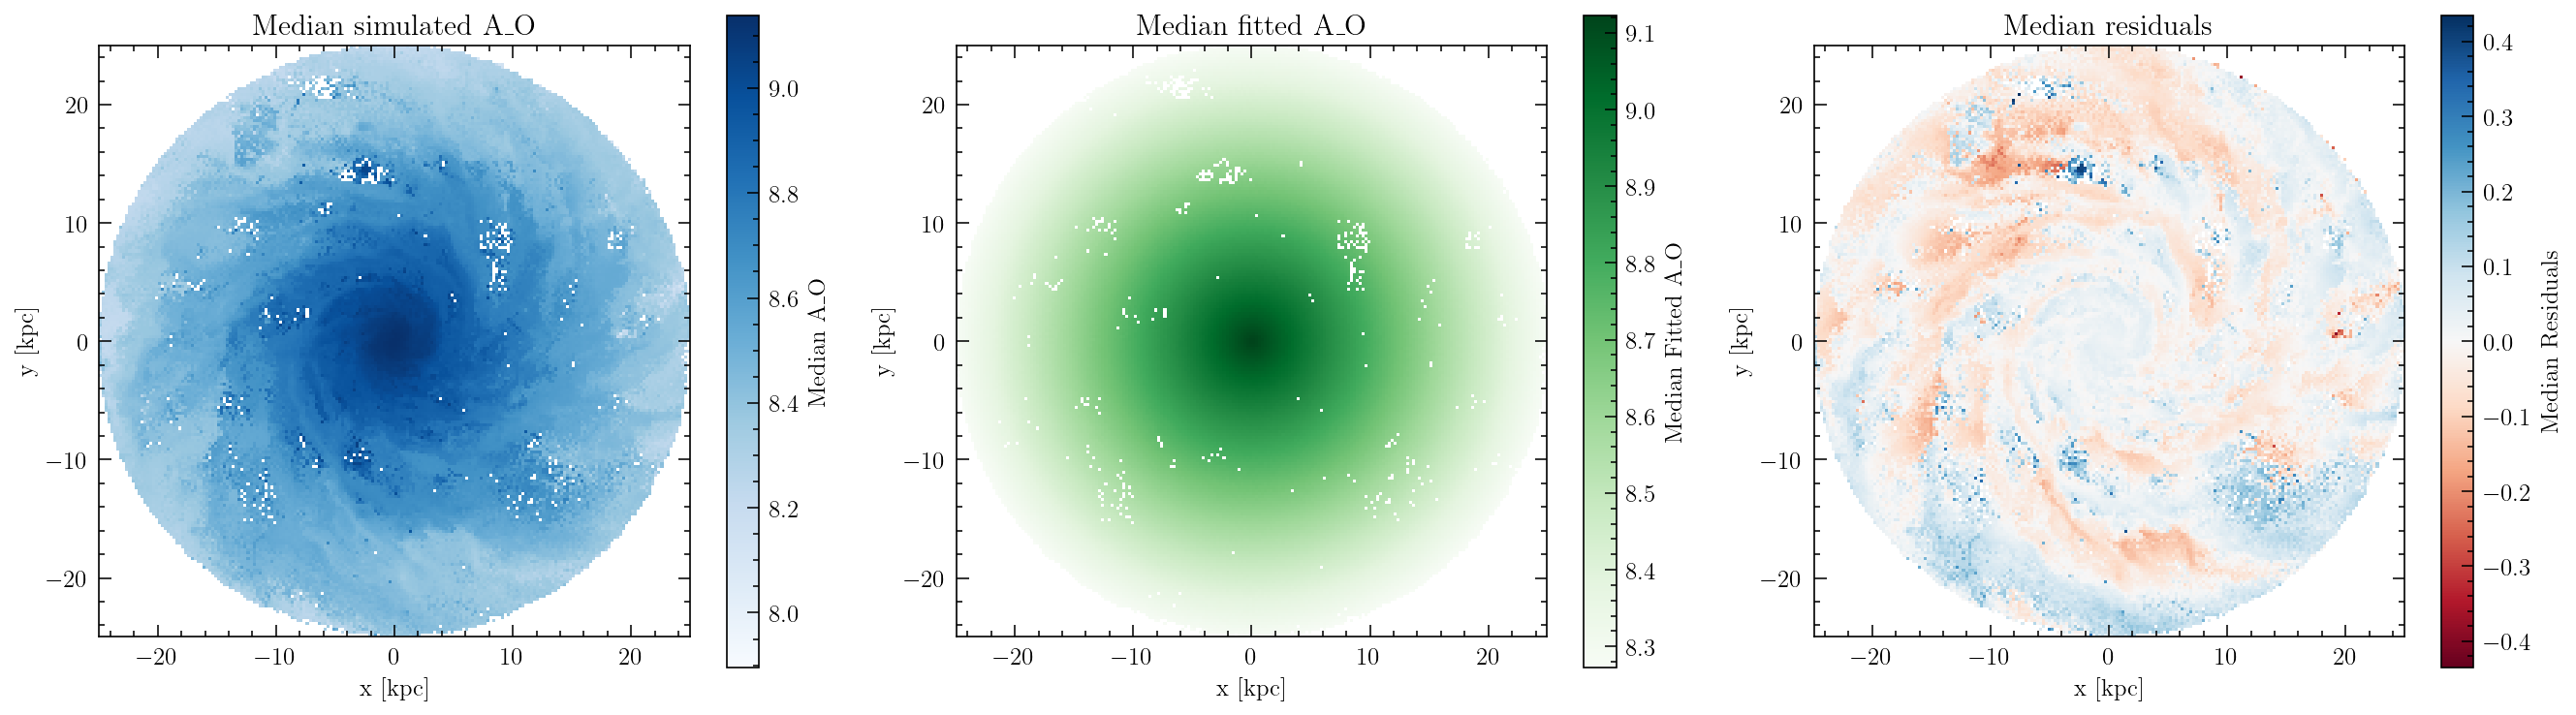

In [56]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, A_O, statistic='median', bins=200)
im = axs[0].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='Blues')
plt.colorbar(im, ax=axs[0], label='Median A_O')
axs[0].set_xlabel('x [kpc]')
axs[0].set_ylabel('y [kpc]')
axs[0].set_title('Median simulated A_O')

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, fitted, statistic='median', bins=200)
im = axs[1].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='Greens')
plt.colorbar(im, ax=axs[1], label='Median Fitted A_O')
axs[1].set_xlabel('x [kpc]')
axs[1].set_ylabel('y [kpc]')
axs[1].set_title('Median fitted A_O')

bin_stat_mean, x_edges, y_edges, binnumber = stats.binned_statistic_2d(x, y, residuals, statistic='median', bins=200)
im = axs[2].imshow(bin_stat_mean, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], origin='lower', cmap='RdBu', norm=colors.CenteredNorm(vcenter=0))
plt.colorbar(im, ax=axs[2], label='Median Residuals')
axs[2].set_xlabel('x [kpc]')
axs[2].set_ylabel('y [kpc]')
axs[2].set_title('Median residuals')

plt.tight_layout()
fig.show()

6.

*Analyse the residuals in more detail and propose a reasonable physical explanation for any patterns you observe.*

In [ ]:
# very clearly see fitted A_O underpredicts A_O in spiral pattern
# due to the overdensities in the spiral arms, which are not captured by a linear fit
# that the true metallicity field could contain azimuthal structure associated with spiral structure / radial mixing / local enrichment

# why does there tend to be positive residual to one side and negative to the other? Is this a projection effect, or is there a physical reason for this?